# Punto 1 — Entendimiento inicial de datos

**Curso:** MINE-4101 Ciencia de Datos Aplicada · 2026-20  
**Dataset:** Contratos de bienes (compraventa y suministros) · SECOP II · 2019–2025  
**Objetivo del taller:** Identificar qué contratos merecen supervisión más cercana por parte de la oficina de control interno.

Este notebook cubre:
1. Carga y descripción general del dataset
2. Tipos de datos y dimensiones
3. Top 5 atributos más relevantes con análisis univariado
4. Identificación y tratamiento de problemas de calidad de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Carga del dataset

In [2]:
df = pd.read_parquet('../data/secop_bienes.parquet')
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head(5)

Filas:    196,391
Columnas: 36


,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 2. Estructura del dataset

In [3]:
# Tipos de datos y conteo de nulos
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().mean() * 100).round(2),
    'únicos': df.nunique()
})
info

,dtype,nulos,nulos_%,únicos
id_contrato,object,0,0.00,196391
nombre_entidad,object,0,0.00,3452
departamento,object,0,0.00,34
ciudad,object,0,0.00,676
orden,object,0,0.00,4
sector,object,0,0.00,26
rama,object,0,0.00,5
entidad_centralizada,object,0,0.00,2
tipo_de_contrato,object,0,0.00,2
modalidad_de_contratacion,object,0,0.00,9


### Clasificación de columnas por tipo

Clasificamos las columnas segun su tipo para facilitar análisis:
- **id**: Se refieren a identificadores que tienen del contrato.
- **Fecha**: Columnas que son fechas
- **Númericas**: Columnas numericas, que pueden ser enteros o decimales.
- **Booleana**: Columnas donde las unicas posibilidades en el valor son SI o NO.
- **Categoricas**: Columnas en tipo texto, que no cumple ninguna de las caracteristicas de arriba.

In [4]:
# Separar columnas por tipo semántico
cols_id       = ['id_contrato', 'urlproceso', 'documento_proveedor', 'proveedor_adjudicado', 'nombre_entidad', 'objeto_del_contrato']
cols_fecha    = ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']
cols_numerica = ['valor_del_contrato', 'valor_pagado', 'valor_facturado', 'valor_pendiente_de_pago', 'dias_adicionados']
# Columnas con únicamente valores Sí/No (habilita_pago_adelantado tiene además "No Definido")
cols_booleana = ['es_pyme', 'es_grupo', 'habilita_pago_adelantado', 'el_contrato_puede_ser_prorrogado',
                 'liquidaci_n', 'obligaci_n_ambiental']
cols_categ    = [c for c in df.columns
                 if c not in cols_id + cols_fecha + cols_numerica + cols_booleana]

print(f'Identificadores  : {len(cols_id)} \n')
print(f'Fechas           : {len(cols_fecha)} \n')
print(f'Numéricas        : {len(cols_numerica)} \n')
print(f'Booleanas (Si/No): {len(cols_booleana)} ')
print(f' {cols_booleana} \n')
print(f'Categóricas      : {len(cols_categ)}')
print(f' {cols_categ}')

Identificadores  : 6 

Fechas           : 3 

Numéricas        : 5 

Booleanas (Si/No): 6 
 ['es_pyme', 'es_grupo', 'habilita_pago_adelantado', 'el_contrato_puede_ser_prorrogado', 'liquidaci_n', 'obligaci_n_ambiental'] 

Categóricas      : 16
 ['departamento', 'ciudad', 'orden', 'sector', 'rama', 'entidad_centralizada', 'tipo_de_contrato', 'modalidad_de_contratacion', 'codigo_de_categoria_principal', 'duraci_n_del_contrato', 'condiciones_de_entrega', 'g_nero_representante_legal', 'nacionalidad_representante_legal', 'origen_de_los_recursos', 'destino_gasto', 'estado_contrato']


### Distribución temporal

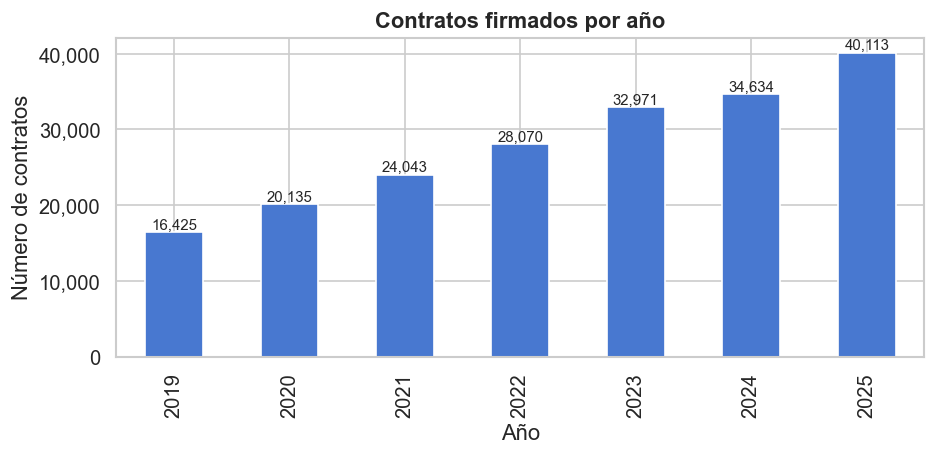

Observación: el volumen crece sostenidamente cada año; 2025 tiene el mayor número de contratos.


In [5]:
contratos_por_anio = df['fecha_de_firma'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
contratos_por_anio.plot(kind='bar', ax=ax, color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_title('Contratos firmados por año', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de contratos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('Observación: el volumen crece sostenidamente cada año; 2025 tiene el mayor número de contratos.')

---
## 3. Top 5 atributos más relevantes

El enunciado define tres señales concretas de desviación del plan de un contrato: **(1) adiciones de plazo**, **(2) presupuesto no ejecutado** y **(3) cierre sin liquidar**. Con ese marco, los cinco atributos se seleccionaron por su capacidad de capturar directamente una o más de esas señales, o de segmentar el riesgo de que ocurran.

### Criterios de selección

**1. `dias_adicionados`**  
Es la medida **directa** de la primera señal de desvío. Un contrato que amplía su vigencia ya incurrió en una desviación del plan original, con el consecuente riesgo de sobrecosto administrativo o retraso en la entrega del bien a la ciudadanía.

**2. `valor_del_contrato`**  
Define la **magnitud del riesgo financiero**. Por sí solo no indica desvío, pero escala el impacto de cualquier problema: una adición de plazo o un presupuesto no ejecutado en un contrato de $500M tiene consecuencias fiscales muy distintas a uno de $10M. Es el principal factor de priorización cuando los recursos de supervisión son escasos.

**3. `estado_contrato`**  
Captura el **estado del ciclo de vida** del contrato. Los estados "Modificado" (17.5% del total) y "Suspendido/Cancelado/Cedido" son señales *ex post* de que ya ocurrió alguna desviación del plan original.

**4. `valor_pagado`**  
Captura directamente la segunda señal del enunciado: **presupuesto no ejecutado**. Comparado con `valor_del_contrato`, permite calcular la **tasa de ejecución** de cada contrato. Un contrato cerrado o terminado con valor pagado muy por debajo del valor contratado indica que los bienes no fueron entregados completamente, generando pérdida de eficiencia del gasto público. A diferencia de `liquidaci_n`, es aplicable a todos los contratos independientemente de su tipo.

**5. `modalidad_de_contratacion`**  
Determina el **nivel de control competitivo y de veeduría externa** del proceso de selección del proveedor. Modalidades como Mínima Cuantía y Contratación Directa tienen menos requisitos de publicidad y comparación de ofertas, lo que históricamente se asocia con mayor riesgo de irregularidades.

> **Variables descartadas del top 5:** `liquidaci_n` fue considerada inicialmente, pero no todos los contratos están obligados a liquidarse (depende del tipo contractual), por lo que no es una señal universal de desvío. `sector`, `destino_gasto` y `orden` aparecerán en el análisis multivariado del punto 3 como variables de segmentación.

### Atributo 1 — `dias_adicionados` (adición de plazo)

In [6]:
dias = df['dias_adicionados']

stats = dias.describe().rename({
    'count': 'n', 'mean': 'media', 'std': 'desv. est.',
    'min': 'mín', '25%': 'Q1', '50%': 'mediana', '75%': 'Q3', 'max': 'máx'
})
display(
    stats.to_frame().T
    .style.format('{:,.1f}')
    .hide(axis='index')
    .set_caption('Estadísticos descriptivos — dias_adicionados')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '6px')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'th, td',
         'props': [('border', '1px solid #cccccc'), ('padding', '6px 12px'), ('text-align', 'right')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]},
    ])
)

print(f'\nContratos con 0 días adicionados   : {(dias == 0).sum():,} ({(dias == 0).mean()*100:.1f}%)')
print(f'Contratos con días adicionados      : {(dias > 0).sum():,} ({(dias > 0).mean()*100:.1f}%)')
print(f'Contratos con > 30 días adicionales : {(dias > 30).sum():,} ({(dias > 30).mean()*100:.1f}%)')
print(f'Contratos con > 180 días adicionales: {(dias > 180).sum():,} ({(dias > 180).mean()*100:.1f}%)')

n,media,desv. est.,mín,Q1,mediana,Q3,máx
"196,391.0",5.1,40.7,0.0,0.0,0.0,0.0,"14,276.0"



Contratos con 0 días adicionados   : 177,720 (90.5%)
Contratos con días adicionados      : 18,671 (9.5%)
Contratos con > 30 días adicionales : 9,434 (4.8%)
Contratos con > 180 días adicionales: 961 (0.5%)


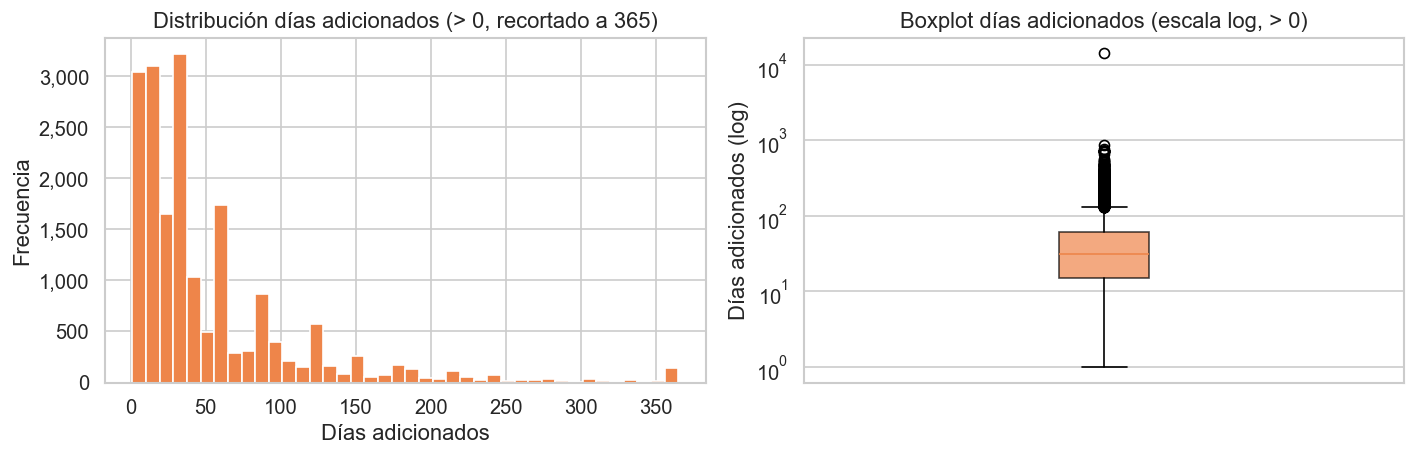

Observación: distribución fuertemente sesgada a la derecha. La mayoría de adiciones son pequeñas (< 60 días), pero existen casos extremos de hasta 14,276 días (~39 años).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma (contratos con días > 0)
dias_pos = dias[dias > 0]
axes[0].hist(dias_pos.clip(upper=365), bins=40, color=sns.color_palette('muted')[1], edgecolor='white')
axes[0].set_title('Distribución días adicionados (> 0, recortado a 365)')
axes[0].set_xlabel('Días adicionados')
axes[0].set_ylabel('Frecuencia')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Boxplot en escala log
axes[1].boxplot(dias_pos, vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.7))
axes[1].set_yscale('log')
axes[1].set_title('Boxplot días adicionados (escala log, > 0)')
axes[1].set_ylabel('Días adicionados (log)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()
print('Observación: distribución fuertemente sesgada a la derecha. La mayoría de adiciones son pequeñas (< 60 días), pero existen casos extremos de hasta 14,276 días (~39 años).')

### Atributo 2 — `valor_del_contrato` (tamaño del riesgo financiero)

In [8]:
valor = df['valor_del_contrato']

stats = valor.describe().rename({
    'count': 'n', 'mean': 'media', 'std': 'desv. est.',
    'min': 'mín', '25%': 'Q1', '50%': 'mediana', '75%': 'Q3', 'max': 'máx'
})

def fmt_valor(col_name, val):
    if col_name == 'n':
        return f'{val:,.0f}'
    return f'${val:,.0f}'

tabla = stats.to_frame().T
display(
    tabla.style
    .format({col: (lambda v, c=col: fmt_valor(c, v)) for col in tabla.columns})
    .hide(axis='index')
    .set_caption('Estadísticos descriptivos — valor_del_contrato (COP)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '6px')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'th, td',
         'props': [('border', '1px solid #cccccc'), ('padding', '6px 12px'), ('text-align', 'right')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]},
    ])
)

print(f'\nContratos con valor = 0         : {(valor == 0).sum():,} ({(valor == 0).mean()*100:.2f}%)')
print(f'Contratos con valor < $1M       : {(valor < 1e6).sum():,} ({(valor < 1e6).mean()*100:.1f}%)')
print(f'Contratos con valor > $1,000M   : {(valor > 1e9).sum():,} ({(valor > 1e9).mean()*100:.1f}%)')

n,media,desv. est.,mín,Q1,mediana,Q3,máx
"196,391","$65,824,255,028","$29,015,352,967,837",$0,"$12,021,214","$33,600,000","$100,000,000","$12,858,450,316,000,000"



Contratos con valor = 0         : 188 (0.10%)
Contratos con valor < $1M       : 3,196 (1.6%)
Contratos con valor > $1,000M   : 7,883 (4.0%)


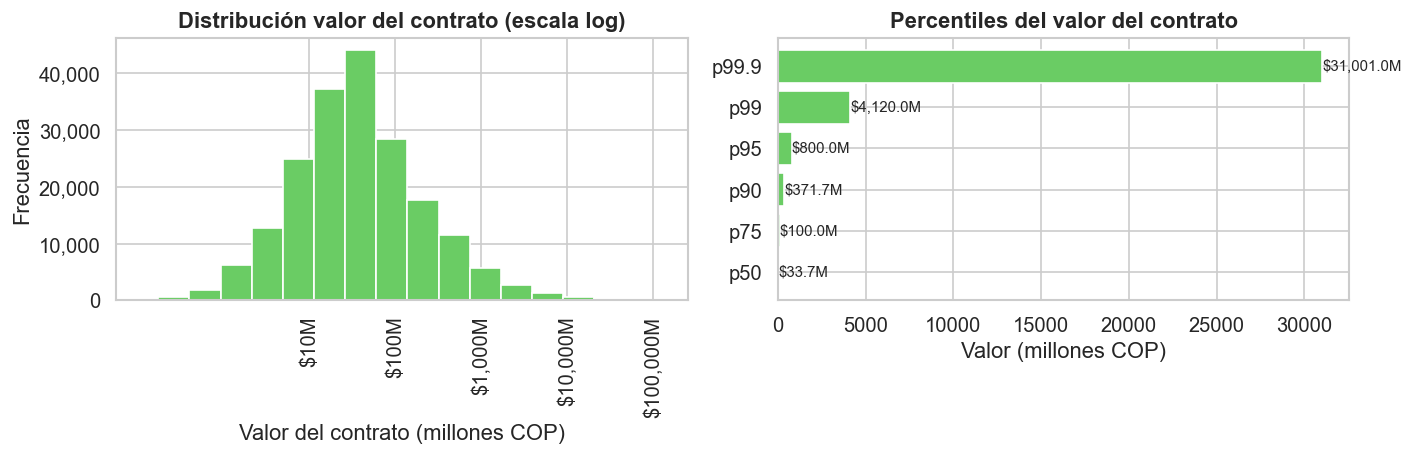

Observación: distribución log-normal. La mediana está en ~$33.6M COP. Los contratos > $1,000M (mil millones) representan el 4% pero concentran un riesgo financiero desproporcionado.


In [9]:
valor_pos = valor[valor > 0]
log_vals  = np.log10(valor_pos)

tick_vals   = [7, 8, 9, 10, 11]
tick_labels = ['$10M', '$100M', '$1,000M', '$10,000M', '$100,000M']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(log_vals, bins=50, color=sns.color_palette('muted')[2], edgecolor='white')
axes[0].set_title('Distribución valor del contrato (escala log)', fontweight='bold')
axes[0].set_xlabel('Valor del contrato (millones COP)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(log_vals.quantile(0.001) - 0.2, max(tick_vals) + 0.4)
axes[0].set_xticks(tick_vals)
axes[0].set_xticklabels(tick_labels, rotation=90)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

percs = [50, 75, 90, 95, 99, 99.9]
vals  = [np.percentile(valor_pos, p) for p in percs]
axes[1].barh([f'p{p}' for p in percs], [v/1e6 for v in vals],
             color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].set_title('Percentiles del valor del contrato', fontweight='bold')
axes[1].set_xlabel('Valor (millones COP)')
for i, v in enumerate(vals):
    axes[1].text(v/1e6 + 0.5, i, f'${v/1e6:,.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('Observación: distribución log-normal. La mediana está en ~$33.6M COP. Los contratos > $1,000M (mil millones) representan el 4% pero concentran un riesgo financiero desproporcionado.')

### Atributo 3 — `estado_contrato`

In [10]:
estado_counts = df['estado_contrato'].value_counts()

print('Distribución de estados:')
print(pd.DataFrame({'n': estado_counts, '%': (estado_counts/len(df)*100).round(1)}).to_string())

Distribución de estados:
                     n     %
estado_contrato             
terminado        54230  27.6
En ejecución     51441  26.2
Cerrado          46824  23.8
Modificado       34462  17.5
Aprobado          9211   4.7
Suspendido         153   0.1
cedido              43   0.0
Cancelado           26   0.0
Borrador             1   0.0


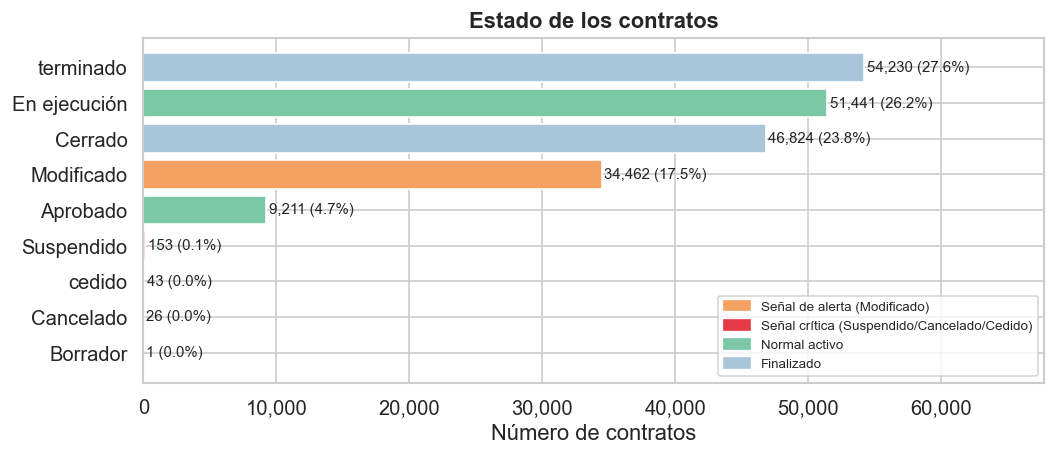

Contratos con señal de alerta (Modificado) : 34,462 (17.5%)
Contratos con señal crítica                : 222 (0.1%)


In [ ]:
# Paleta: resaltar los estados problemáticos
colores = {
    'terminado': '#a8c5da',
    'Cerrado': '#a8c5da',
    'En ejecución': '#7bc8a4',
    'Aprobado': '#7bc8a4',
    'Modificado': '#f4a261',
    'Suspendido': '#e63946',
    'cedido': '#e63946',
    'Cancelado': '#e63946',
    'Borrador': '#cccccc'
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(estado_counts.index[::-1], estado_counts.values[::-1],
               color=[colores.get(s, '#cccccc') for s in estado_counts.index[::-1]], edgecolor='white')
ax.set_title('Estado de los contratos', fontweight='bold')
ax.set_xlabel('Número de contratos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, estado_counts.values[::-1]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, estado_counts.max() * 1.25)

from matplotlib.patches import Patch
leyenda = [Patch(color='#f4a261', label='Modificado'),
           Patch(color='#e63946', label='Suspendido/Cancelado/Cedido'),
           Patch(color='#7bc8a4', label='Normal activo'),
           Patch(color='#a8c5da', label='Finalizado')]
ax.legend(handles=leyenda, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

n_alerta = estado_counts.get('Modificado', 0)
n_critico = estado_counts.get('Suspendido', 0) + estado_counts.get('cedido', 0) + estado_counts.get('Cancelado', 0)
print(f'Contratos con señal de alerta (Modificado) : {n_alerta:,} ({n_alerta/len(df)*100:.1f}%)')
print(f'Contratos con señal crítica                : {n_critico:,} ({n_critico/len(df)*100:.1f}%)')

### Atributo 4 — `valor_pagado` (ejecución presupuestal)

In [ ]:
pagado = df['valor_pagado']
contrato = df['valor_del_contrato']

stats_p = pagado.describe().rename({
    'count': 'n', 'mean': 'media', 'std': 'desv. est.',
    'min': 'mín', '25%': 'Q1', '50%': 'mediana', '75%': 'Q3', 'max': 'máx'
})
display(
    stats_p.to_frame().T
    .style.format(lambda x: f'{x:,.0f}')
    .hide(axis='index')
    .set_caption('Estadísticos descriptivos — valor_pagado (COP)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '6px')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%')]},
        {'selector': 'th, td',
         'props': [('border', '1px solid #cccccc'), ('padding', '6px 12px'), ('text-align', 'right')]},
        {'selector': 'th',
         'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]},
    ])
)

# Tasa de ejecución solo en contratos con valor > 0
mask = contrato > 0
tasa = (pagado[mask] / contrato[mask]).clip(0, 1)

print(f'\nContratos con valor_pagado = 0      : {(pagado == 0).sum():,} ({(pagado == 0).mean()*100:.1f}%)')
print(f'Contratos con ejecución < 50%       : {(tasa < 0.5).sum():,} ({(tasa < 0.5).mean()*100:.1f}% de los que tienen valor > 0)')
print(f'Contratos con ejecución >= 90%      : {(tasa >= 0.9).sum():,} ({(tasa >= 0.9).mean()*100:.1f}%)')
print(f'Contratos con ejecución = 100%      : {(tasa == 1.0).sum():,} ({(tasa == 1.0).mean()*100:.1f}%)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de la tasa de ejecución (excluye contratos en ejecución con pagado=0 esperado)
df_fin = df[df['estado_contrato'].isin(['Cerrado', 'terminado']) & (contrato > 0)].copy()
tasa_fin = (df_fin['valor_pagado'] / df_fin['valor_del_contrato']).clip(0, 1)

axes[0].hist(tasa_fin, bins=40, color=sns.color_palette('muted')[4], edgecolor='white')
axes[0].set_title('Tasa de ejecución — contratos Cerrados/Terminados', fontweight='bold')
axes[0].set_xlabel('valor_pagado / valor_del_contrato')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Barras: distribución por tramo de ejecución
tramos = ['0%', '1–49%', '50–89%', '90–99%', '100%']
counts = [
    (tasa_fin == 0).sum(),
    ((tasa_fin > 0) & (tasa_fin < 0.5)).sum(),
    ((tasa_fin >= 0.5) & (tasa_fin < 0.9)).sum(),
    ((tasa_fin >= 0.9) & (tasa_fin < 1.0)).sum(),
    (tasa_fin == 1.0).sum(),
]
colores_tramo = ['#e63946', '#f4a261', '#ffd166', '#7bc8a4', '#a8c5da']
bars = axes[1].bar(tramos, counts, color=colores_tramo, edgecolor='white')
axes[1].set_title('Contratos Cerrados/Terminados por tramo de ejecución', fontweight='bold')
axes[1].set_xlabel('Tasa de ejecución')
axes[1].set_ylabel('Número de contratos')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'{val:,}\n({val/len(tasa_fin)*100:.1f}%)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(f'Observación: de los {len(tasa_fin):,} contratos cerrados/terminados, '
      f'{(tasa_fin < 0.5).sum():,} ({(tasa_fin < 0.5).mean()*100:.1f}%) tienen una ejecución menor al 50%, '
      f'lo que indica presupuesto no ejecutado como señal de desvío.')

### Atributo 5 — `modalidad_de_contratacion`

In [14]:
modal = df['modalidad_de_contratacion'].value_counts()

# Agrupar modalidades similares para claridad
agrupacion = {
    'Mínima cuantía': 'Mínima cuantía',
    'Selección abreviada subasta inversa': 'Selección abreviada',
    'Selección Abreviada de Menor Cuantía': 'Selección abreviada',
    'Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes': 'Selección abreviada',
    'Contratación régimen especial': 'Régimen especial',
    'Contratación régimen especial (con ofertas)': 'Régimen especial',
    'Contratación Directa (con ofertas)': 'Contratación directa',
    'Contratación directa': 'Contratación directa',
    'Licitación pública': 'Licitación pública',
}
df['modalidad_agrupada'] = df['modalidad_de_contratacion'].map(agrupacion).fillna('Otra')
modal_agrup = df['modalidad_agrupada'].value_counts()

print('Modalidades agrupadas:')
print(pd.DataFrame({'n': modal_agrup, '%': (modal_agrup/len(df)*100).round(1)}).to_string())

Modalidades agrupadas:
                           n     %
modalidad_agrupada                
Mínima cuantía        117753  60.0
Selección abreviada    41965  21.4
Régimen especial       25404  12.9
Contratación directa    8939   4.6
Licitación pública      2330   1.2


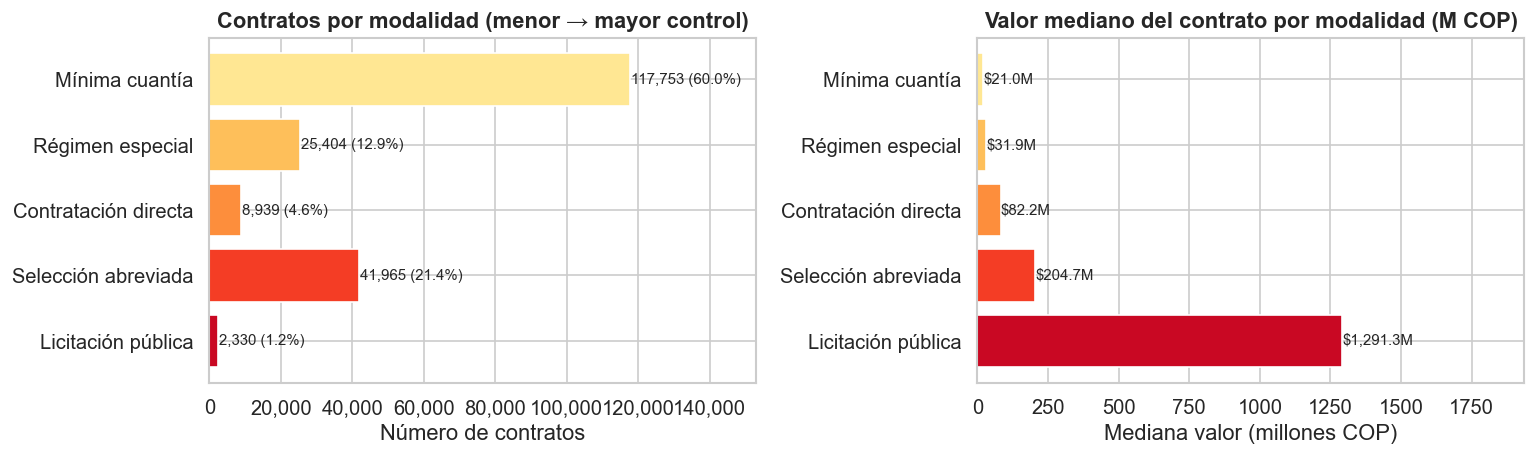

Observación: el 60% de los contratos son de Mínima Cuantía (menor control), pero la Licitación Pública concentra los contratos de mayor valor. La Contratación Directa combina montos medianos con control reducido.


In [15]:
# Orden de control de menor a mayor (para el eje)
orden_control = ['Licitación pública', 'Selección abreviada', 'Contratación directa', 'Régimen especial', 'Mínima cuantía', 'Otra']
modal_ordenada = modal_agrup.reindex([o for o in orden_control if o in modal_agrup.index])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras por número de contratos
colores_modal = sns.color_palette('YlOrRd_r', len(modal_ordenada))
axes[0].barh(modal_ordenada.index, modal_ordenada.values, color=colores_modal, edgecolor='white')
axes[0].set_title('Contratos por modalidad (menor → mayor control)', fontweight='bold')
axes[0].set_xlabel('Número de contratos')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (idx, val) in enumerate(modal_ordenada.items()):
    axes[0].text(val + 300, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
axes[0].set_xlim(0, modal_ordenada.max() * 1.3)

# Valor mediano del contrato por modalidad
mediana_valor = df.groupby('modalidad_agrupada')['valor_del_contrato'].median() / 1e6
mediana_valor = mediana_valor.reindex([o for o in orden_control if o in mediana_valor.index])
axes[1].barh(mediana_valor.index, mediana_valor.values, color=colores_modal, edgecolor='white')
axes[1].set_title('Valor mediano del contrato por modalidad (M COP)', fontweight='bold')
axes[1].set_xlabel('Mediana valor (millones COP)')
for i, (idx, val) in enumerate(mediana_valor.items()):
    axes[1].text(val + 0.5, i, f'${val:,.1f}M', va='center', fontsize=9)
axes[1].set_xlim(0, mediana_valor.max() * 1.5)

plt.tight_layout()
plt.show()
print('Observación: el 60% de los contratos son de Mínima Cuantía (menor control), pero la Licitación Pública concentra los contratos de mayor valor. La Contratación Directa combina montos medianos con control reducido.')

---
## 4. Problemas de calidad de datos identificados y tratamiento

Los siguientes problemas fueron identificados durante la exploración inicial:

In [16]:
# --- Problema 1: contratos con valor_del_contrato = 0 ---
n_valor_cero = (df['valor_del_contrato'] == 0).sum()
print(f'[P1] Contratos con valor_del_contrato = 0: {n_valor_cero:,} ({n_valor_cero/len(df)*100:.2f}%)')
print('     → Posibles errores de registro o contratos a monto agotable sin definir.')
print('     Tratamiento: se excluirán del análisis financiero (mantener para análisis de estado/modalidad).')

print()
# --- Problema 2: valor_del_contrato con outliers extremos ---
p999 = df['valor_del_contrato'].quantile(0.999)
n_extremos = (df['valor_del_contrato'] > p999).sum()
print(f'[P2] Contratos con valor > p99.9 (${p999/1e6:,.0f}M): {n_extremos:,} ({n_extremos/len(df)*100:.3f}%)')
max_val = df['valor_del_contrato'].max()
print(f'     Valor máximo: ${max_val/1e6:,.0f}M COP (~${max_val/1e12:.1f} billones)')
print('     Tratamiento: revisar si son contratos marco o errores de digitación. Se analizarán separadamente.')

print()
# --- Problema 3: valor_pendiente_de_pago negativo ---
n_neg = (df['valor_pendiente_de_pago'] < 0).sum()
print(f'[P3] Contratos con valor_pendiente_de_pago < 0: {n_neg:,}')
print(f'     Mínimo: ${df["valor_pendiente_de_pago"].min():,} COP')
print('     Tratamiento: imputar a 0 (posiblemente ajustes contables o anticipos recuperados).')

print()
# --- Problema 4: días_adicionados con valores extremos ---
n_dias_extremos = (df['dias_adicionados'] > 1825).sum()
print(f'[P4] Contratos con dias_adicionados > 5 años: {n_dias_extremos:,}')
print(f'     Máximo: {df["dias_adicionados"].max():,} días (~{df["dias_adicionados"].max()/365:.0f} años)')
print('     Tratamiento: marcar como outliers; analizar separadamente pero no excluir del conteo de desvíos.')

print()
# --- Problema 5: fecha_de_inicio_del_contrato nula ---
n_fecha_nula = df['fecha_de_inicio_del_contrato'].isnull().sum()
print(f'[P5] Contratos sin fecha_de_inicio: {n_fecha_nula:,} ({n_fecha_nula/len(df)*100:.2f}%)')
print('     Tratamiento: usar fecha_de_firma como proxy cuando se necesite la fecha de inicio.')

print()
# --- Problema 6: duraci_n_del_contrato — columna de texto inconsistente ---
print(f'[P6] Valores únicos de duraci_n_del_contrato (top 10):')
print(df['duraci_n_del_contrato'].value_counts().head(10).to_string())
print('     Tratamiento: columna no utilizable directamente. Se calculará duración a partir de fechas de inicio/fin.')

[P1] Contratos con valor_del_contrato = 0: 188 (0.10%)
     → Posibles errores de registro o contratos a monto agotable sin definir.
     Tratamiento: se excluirán del análisis financiero (mantener para análisis de estado/modalidad).

[P2] Contratos con valor > p99.9 ($30,959M): 197 (0.100%)
     Valor máximo: $12,858,450,316M COP (~$12858.5 billones)
     Tratamiento: revisar si son contratos marco o errores de digitación. Se analizarán separadamente.

[P3] Contratos con valor_pendiente_de_pago < 0: 144
     Mínimo: $-84,184,884 COP
     Tratamiento: imputar a 0 (posiblemente ajustes contables o anticipos recuperados).

[P4] Contratos con dias_adicionados > 5 años: 1
     Máximo: 14,276 días (~39 años)
     Tratamiento: marcar como outliers; analizar separadamente pero no excluir del conteo de desvíos.

[P5] Contratos sin fecha_de_inicio: 2,440 (1.24%)
     Tratamiento: usar fecha_de_firma como proxy cuando se necesite la fecha de inicio.

[P6] Valores únicos de duraci_n_del_contrato 

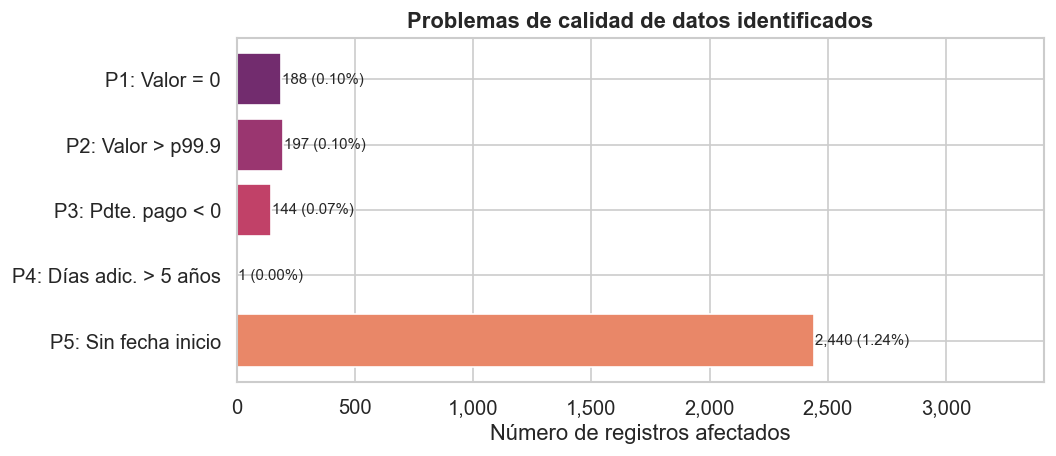

El dataset tiene buena calidad general. Los problemas son manejables y están concentrados principalmente en valores extremos de las variables financieras.


In [17]:
# Resumen visual de problemas de calidad
problemas = {
    'P1: Valor = 0': n_valor_cero,
    'P2: Valor > p99.9': n_extremos,
    'P3: Pdte. pago < 0': n_neg,
    'P4: Días adic. > 5 años': n_dias_extremos,
    'P5: Sin fecha inicio': n_fecha_nula,
}

fig, ax = plt.subplots(figsize=(9, 4))
probs = pd.Series(problemas)
ax.barh(probs.index[::-1], probs.values[::-1], color=sns.color_palette('flare', len(probs)), edgecolor='white')
ax.set_title('Problemas de calidad de datos identificados', fontweight='bold')
ax.set_xlabel('Número de registros afectados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(ax.patches, probs.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.2f}%)', va='center', fontsize=9)
ax.set_xlim(0, probs.max() * 1.4)
plt.tight_layout()
plt.show()
print('El dataset tiene buena calidad general. Los problemas son manejables y están concentrados principalmente en valores extremos de las variables financieras.')

---
## 5. Tabla resumen de los 5 atributos clave

| Atributo | Tipo | Señal de desvío | Hallazgo principal |
|---|---|---|---|
| `dias_adicionados` | Numérica | Adición de plazo | 9.5% de contratos con > 0 días; outliers extremos (hasta 39 años) |
| `valor_del_contrato` | Numérica | Magnitud del riesgo financiero | Distribución log-normal; mediana ~$33.6M; 4% supera $1,000M |
| `estado_contrato` | Categórica | Estado del ciclo de vida | 17.5% Modificados; 0.1% Suspendidos/Cancelados |
| `valor_pagado` | Numérica | Presupuesto no ejecutado | Gran concentración en 0% y 100% de ejecución; señal clave en contratos finalizados |
| `modalidad_de_contratacion` | Categórica | Nivel de control competitivo | 60% Mínima Cuantía; Contratación Directa: alto valor + bajo control |

**Decisión sobre el período de análisis:**  
El dataset cubre 2019–2025. Se recomienda trabajar con **2020–2024** como período principal por las siguientes razones:
- 2019 tiene el menor volumen y puede estar incompleto en SECOP II (plataforma en adopción).
- 2025 está en curso; muchos contratos aún no tienen estado final ni pagos completos registrados, lo que sesgaría los indicadores de ejecución.
- El período 2020–2024 incluye el impacto COVID (2020–2021) y la normalización posterior, lo que permite comparaciones significativas.